# Rotation
Tilts the user space

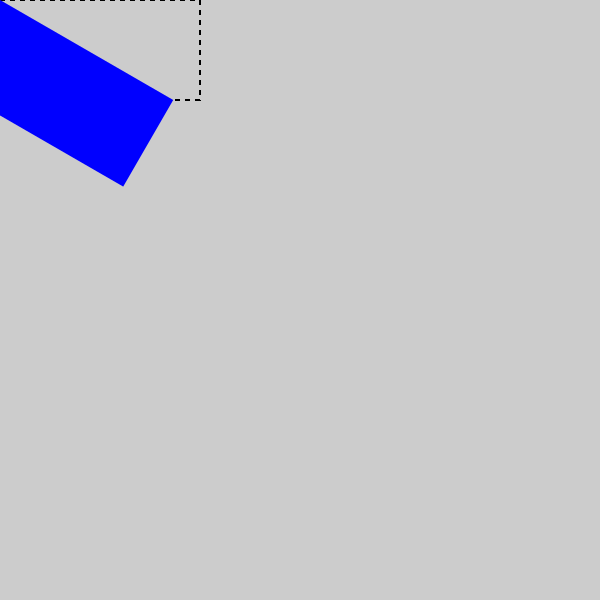

In [12]:
import cairo
from IPython.core.display import Image
import math

surface = cairo.ImageSurface(cairo.FORMAT_RGB24, 600, 600)
ctx = cairo.Context(surface)
ctx.set_source_rgb(0.8, 0.8, 0.8)
ctx.paint()

x, y, w, h = 0,0,200,100

ctx.set_source_rgb(0,0,0)
ctx.rectangle(x,y,w,h)
ctx.set_dash([5,5])
ctx.stroke()

ctx.rotate(math.radians(30))

ctx.set_source_rgb(0,0,1)
ctx.rectangle(x,y,w,h)
ctx.fill()

surface.write_to_png("ex.png")
Image("ex.png")

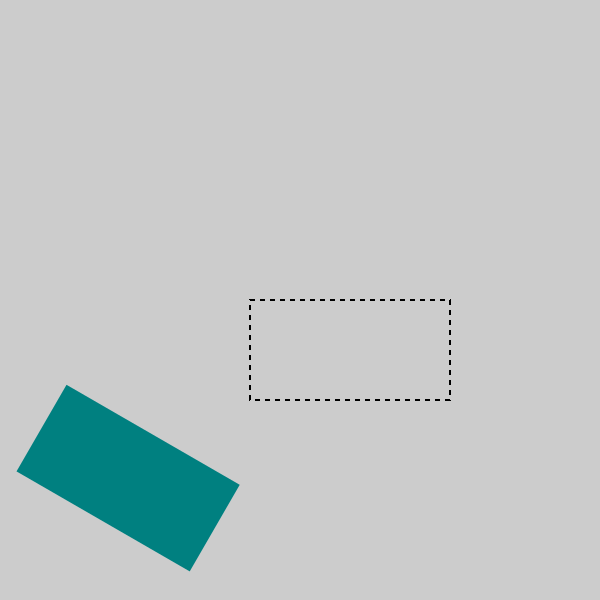

In [1]:
import cairo
import math
from IPython.core.display import Image

surface = cairo.ImageSurface(cairo.FORMAT_RGB24, 600, 600)
ctx = cairo.Context(surface)
ctx.set_source_rgb(0.8, 0.8, 0.8)
ctx.paint()

x, y = 250, 300
width, height = 200, 100

# Before rotation
ctx.set_source_rgb(0, 0, 0)
ctx.rectangle(x, y, width, height)
ctx.set_dash([5, 5])
ctx.stroke()

# Rotation
ctx.rotate(math.radians(30))

# After rotation
ctx.set_source_rgb(0, 0.5, 0.5)
ctx.rectangle(x, y, width, height)
ctx.fill()

surface.write_to_png('rotation.png')
Image('rotation.png')

## Rotation about a point
- Translate by `(cx, cy)`
- Rotate by `r`
- Translate by `(-cx, -cy)`

- ctx.translate(cx, cy)
	- The origin (0,0) is shifted to (cx, cy) in the coordinate system.
    - Now, any transformations (like rotate) will occur relative to this new origin.
-  ctx.rotate(math.pi / 6)
    - The coordinate system is rotated by 30∘ around the new origin at (cx, cy).
    - This means that any points or shapes you draw after this will be rotated relative to the center of the rectangle.
-  ctx.translate(cx, cy)
    - This step shifts the origin back to (0,0) in the coordinate system.
    - However, and this is key:
        - The rotation transformation applied earlier is still in effect.
        - Only the coordinate system's origin is moved back to (0,0), but the rotation remains.
-  ctx.rectangle(200, 300, 200, 100)
    - You are now drawing the rectangle at its original position (200,300) in user space.
    - However, since the coordinate system is still rotated, the rectangle appears rotated around its center (cx, cy).


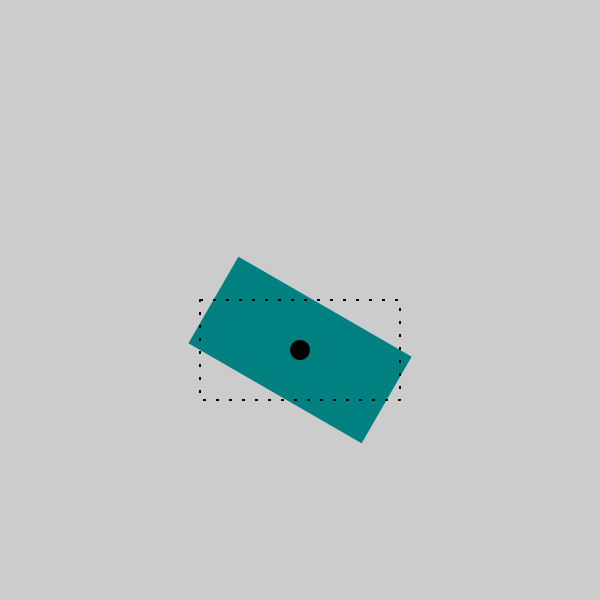

In [11]:
import cairo
import math
from IPython.core.display import Image

surface = cairo.ImageSurface(cairo.FORMAT_RGB24, 600, 600)
ctx = cairo.Context(surface)
ctx.set_source_rgb(0.8, 0.8, 0.8)
ctx.paint()

x, y = 200, 300
width, height = 200, 100
cx = x + width//2
cy = y + height//2

ctx.save()

# Rotation
ctx.translate(cx, cy)
ctx.rotate(math.radians(30))
ctx.translate(-cx, -cy)

# After rotation
ctx.set_source_rgb(0, 0.5, 0.5)
ctx.rectangle(x, y, width, height)
ctx.fill()

ctx.restore()

# Outline showing shape without rotation
ctx.set_source_rgb(0, 0, 0)
ctx.arc(cx, cy, 10, 0, math.radians(360))
ctx.fill()

ctx.set_line_width(2)
ctx.rectangle(x, y, width, height)
ctx.set_dash([5, 5])
ctx.stroke()

surface.write_to_png('rotation.png')
Image('rotation.png')